## 1. Setup and Imports

In [2]:
import os
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


In [3]:

# Define paths
BASE_DIR = Path("../data")
IMAGES_DIR = BASE_DIR / "book_images"
OUTPUT_DIR = BASE_DIR / "quiz_sections"

print(f"Images directory: {IMAGES_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

# Check if images directory exists
if IMAGES_DIR.exists():
    image_files = sorted([f for f in IMAGES_DIR.glob("*") if f.suffix.lower() in ['.png', '.jpg', '.jpeg']])
    print(f"\nFound {len(image_files)} images:")
    for i, img in enumerate(image_files):
        print(f"  {i+1}. {img.name}")
else:
    print(f"ERROR: {IMAGES_DIR} does not exist!")

Images directory: ..\data\book_images
Output directory: ..\data\quiz_sections

Found 20 images:
  1. test-01.jpg
  2. test-02.jpg
  3. test-03.jpg
  4. test-04.jpg
  5. test-05.jpg
  6. test-06.jpg
  7. test-07.jpg
  8. test-08.jpg
  9. test-09.jpg
  10. test-10.jpg
  11. test-11.jpg
  12. test-12.jpg
  13. test-13.jpg
  14. test-14.jpg
  15. test-15.jpg
  16. test-16.jpg
  17. test-17.jpg
  18. test-18.jpg
  19. test-19.jpg
  20. test-20.jpg


## 2. Load and Inspect First Image

First image: test-14.jpg
Image shape: (1409, 1024, 3)
Height: 1409 px
Width: 1024 px


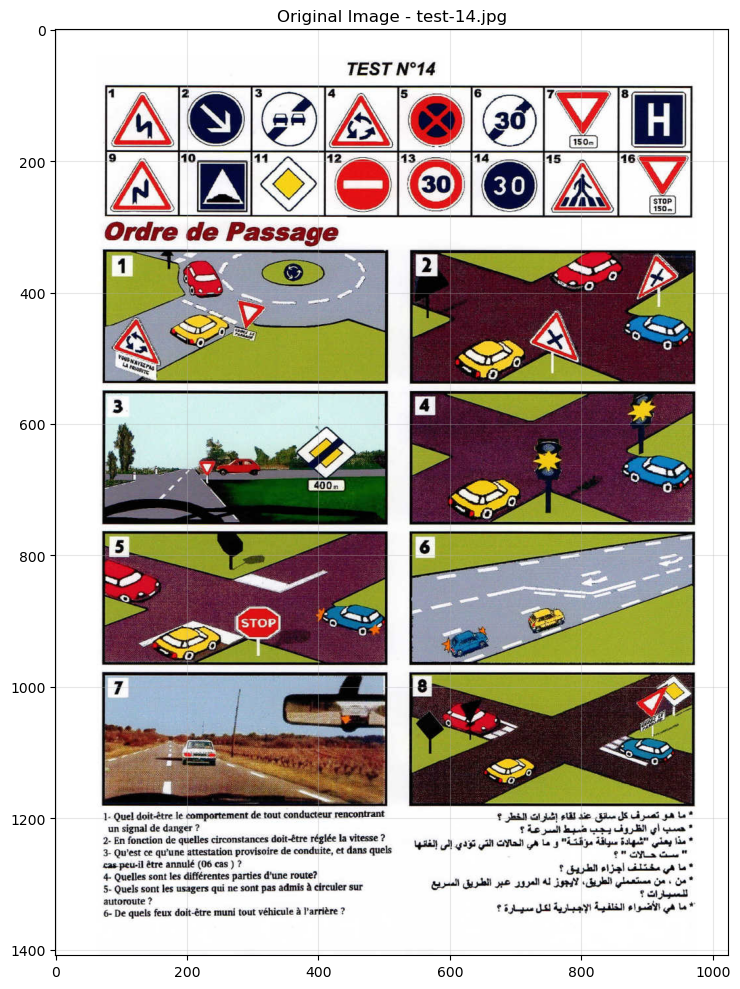

In [4]:
# Load first image to analyze dimensions
if image_files:
    first_image_path = image_files[13]
    img = cv2.imread(str(first_image_path))
    
    print(f"First image: {first_image_path.name}")
    print(f"Image shape: {img.shape}")
    print(f"Height: {img.shape[0]} px")
    print(f"Width: {img.shape[1]} px")
    
    # Display the image
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Original Image - {first_image_path.name}")
    plt.axis('on')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No images found!")

## 3. Detect Section Boundaries by Color

We'll detect the black borders that separate the three sections.

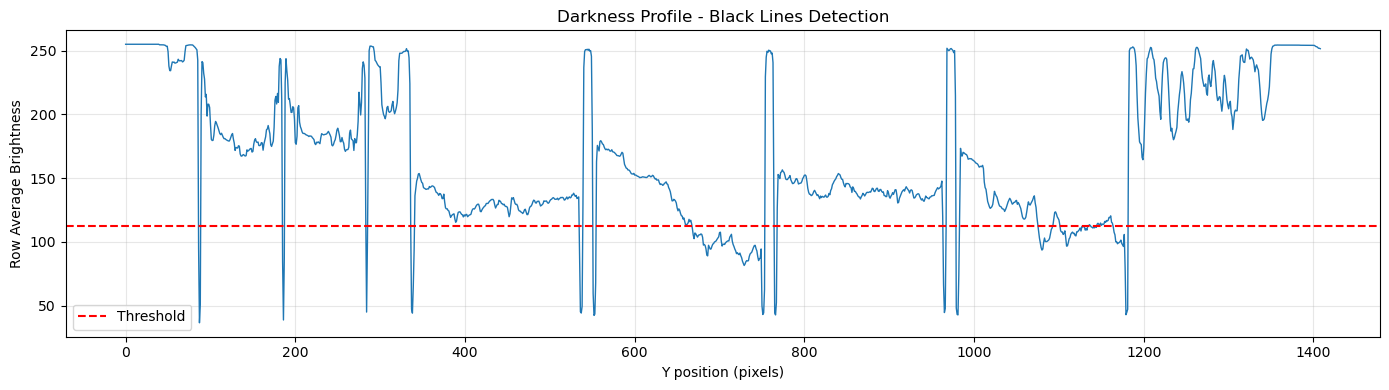

Detected 25 dark pixels/rows
Darkness threshold: 112.61


In [ ]:
def detect_black_lines(img):
    """
    Detect horizontal black lines (borders) in the image.
    Returns the y-coordinates of significant black lines.
    """
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Calculate the "blackness" of each row (how many dark pixels)
    # A black line will have very low average values
    row_darkness = []
    for y in range(gray.shape[0]):
        row = gray[y, :]
        darkness = np.mean(row)  # Lower values = darker
        row_darkness.append(darkness)
    
    row_darkness = np.array(row_darkness)
    
    # Find rows that are significantly darker (likely black borders)
    threshold = np.mean(row_darkness) - np.std(row_darkness)
    black_rows = np.where(row_darkness < threshold)[0]
    
    return row_darkness, black_rows


# Detect black lines
row_darkness, black_rows = detect_black_lines(img)

# Plot darkness profile to visualize
plt.figure(figsize=(14, 4))
plt.plot(row_darkness, linewidth=1)
plt.axhline(y=np.mean(row_darkness) - np.std(row_darkness), color='r', linestyle='--', label='Threshold')
plt.xlabel('Y position (pixels)')
plt.ylabel('Row Average Brightness')
plt.title('Darkness Profile - Black Lines Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Detected {len(black_rows)} dark pixels/rows")
print(f"Darkness threshold: {np.mean(row_darkness) - np.std(row_darkness):.2f}")

## 4. Find Cluster Centers of Black Lines

Group continuous black pixels into distinct lines and find their centers.

In [89]:
def find_border_lines(black_rows, min_gap=30):
    """
    Find distinct black border lines by clustering continuous black pixels.
    
    Args:
        black_rows: Array of y-coordinates with black pixels
        min_gap: Minimum gap to consider as separate lines (pixels)
    
    Returns:
        List of border line positions (y-coordinates)
    """
    if len(black_rows) == 0:
        return []
    
    # Group continuous black pixels
    borders = []
    current_group = [black_rows[0]]
    
    for i in range(1, len(black_rows)):
        if black_rows[i] - black_rows[i-1] <= min_gap:
            current_group.append(black_rows[i])
        else:
            # End current group, calculate center
            border_center = int(np.mean(current_group))
            borders.append(border_center)
            current_group = [black_rows[i]]
    
    # Don't forget the last group
    if current_group:
        border_center = int(np.mean(current_group))
        borders.append(border_center)
    
    return borders


borders = find_border_lines(black_rows, min_gap=40)
print(f"Found {len(borders)} border lines at y-positions:")
for i, border in enumerate(borders):
    print(f"  {i}. y = {border}")

Found 8 border lines at y-positions:
  0. y = 87
  1. y = 186
  2. y = 284
  3. y = 338
  4. y = 544
  5. y = 712
  6. y = 973
  7. y = 1125


## 5. Define Section Boundaries

Based on the detected borders, define the three sections:
- SIGNS: Top section
- PRIORITIES: Middle section  
- QUESTIONS: Bottom section

In [105]:
def define_sections(borders, img_height):
    """
    Define the three main sections based on fixed proportions.
    
    Args:
        borders: List of detected border y-coordinates (not used, kept for compatibility)
        img_height: Total image height
    
    Returns:
        Dictionary with section boundaries
    """
    # Fixed proportions based on typical image of ~1400px height:
    # SIGNS: 0-370px (~26.4%)
    # PRIORITIES: 370-1170px (~57.1% from top)
    # QUESTIONS: 1170px-end (~83.6% from top)
    
    signs_end = int(img_height * 0.21)  # ~26.4% of height
    priorities_end = int(img_height * 0.84)  # ~83.6% of height
    
    sections = {
        'signs': {
            'y_start': 0,
            'y_end': signs_end,
            'name': 'SIGNS (Top)'
        },
        'priorities': {
            'y_start': signs_end,
            'y_end': priorities_end,
            'name': 'PRIORITIES / Ordre de Passage (Middle)'
        },
        'questions': {
            'y_start': priorities_end,
            'y_end': img_height,
            'name': 'QUESTIONS (Bottom)'
        }
    }
    
    return sections


sections = define_sections(borders, img.shape[0])

print("Section definitions:")
for section_name, bounds in sections.items():
    height = bounds['y_end'] - bounds['y_start']
    print(f"\n{section_name.upper()}")
    print(f"  Name: {bounds['name']}")
    print(f"  Y range: {bounds['y_start']} - {bounds['y_end']}")
    print(f"  Height: {height} px")

Section definitions:

SIGNS
  Name: SIGNS (Top)
  Y range: 0 - 295
  Height: 295 px

PRIORITIES
  Name: PRIORITIES / Ordre de Passage (Middle)
  Y range: 295 - 1183
  Height: 888 px

QUESTIONS
  Name: QUESTIONS (Bottom)
  Y range: 1183 - 1409
  Height: 226 px


## 6. Visualize Detected Sections

Show the original image with lines marking the section boundaries.

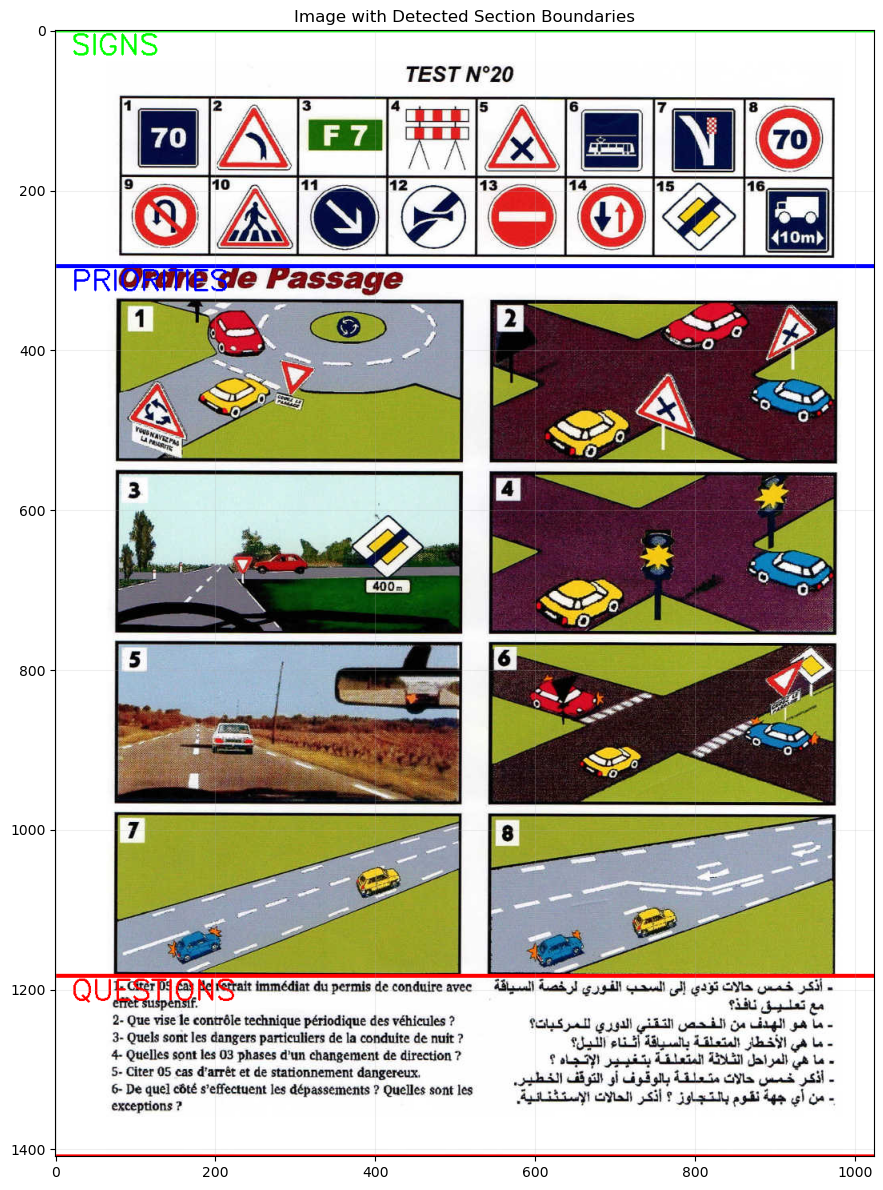

Section boundaries mared on image:
  GREEN = SIGNS
  RED = PRIORITIES
  BLUE = QUESTIONS


In [106]:
# Create visualization with section boundaries
img_marked = img.copy()
colors = {'signs': (0, 255, 0), 'priorities': (255, 0, 0), 'questions': (0, 0, 255)}

for section_name, bounds in sections.items():
    y_start = bounds['y_start']
    y_end = bounds['y_end']
    
    # Draw lines at boundaries
    cv2.line(img_marked, (0, y_start), (img.shape[1], y_start), colors[section_name], 3)
    cv2.line(img_marked, (0, y_end), (img.shape[1], y_end), colors[section_name], 3)
    
    # Add label
    cv2.putText(img_marked, section_name.upper(), (20, y_start + 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, colors[section_name], 2)

plt.figure(figsize=(14, 12))
plt.imshow(cv2.cvtColor(img_marked, cv2.COLOR_BGR2RGB))
plt.title("Image with Detected Section Boundaries")
plt.axis('on')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Section boundaries mar" \
"ed on image:")
print("  GREEN = SIGNS")
print("  RED = PRIORITIES")
print("  BLUE = QUESTIONS")

## 7. Extract and Save Sections

Crop the three sections from the image and save them.

In [107]:
def extract_sections(img_path, sections, output_base_dir):
    """
    Extract sections from an image and save them to separate files.
    
    Args:
        img_path: Path to the image
        sections: Dictionary with section boundaries
        output_base_dir: Base output directory
    
    Returns:
        Dictionary with paths to saved sections
    """
    img = cv2.imread(str(img_path))
    image_stem = img_path.stem  # Filename without extension
    
    saved_paths = {}
    
    for section_name, bounds in sections.items():
        # Create section directory if it doesn't exist
        section_dir = output_base_dir / image_stem / section_name.upper()
        section_dir.mkdir(parents=True, exist_ok=True)
        
        # Crop the section
        y_start = bounds['y_start']
        y_end = bounds['y_end']
        cropped = img[y_start:y_end, :]
        
        # Save the cropped section
        output_path = section_dir / f"{image_stem}_{section_name}.png"
        cv2.imwrite(str(output_path), cropped)
        
        saved_paths[section_name] = str(output_path)
        
    return saved_paths


# Extract sections from first image as test
if image_files:
    saved_paths = extract_sections(first_image_path, sections, OUTPUT_DIR)
    
    print(f"Extracted sections from: {first_image_path.name}")
    for section_name, path in saved_paths.items():
        print(f"  {section_name.upper()}: {path}")

Extracted sections from: test-14.jpg
  SIGNS: ..\data\quiz_sections\test-14\SIGNS\test-14_signs.png
  PRIORITIES: ..\data\quiz_sections\test-14\PRIORITIES\test-14_priorities.png
  QUESTIONS: ..\data\quiz_sections\test-14\QUESTIONS\test-14_questions.png


## 8. Process All Images

Apply the same section division to all images in the dataset.

In [108]:
# Process all images
processed_count = 0
error_count = 0

for img_path in image_files:
    try:
        print(f"Processing: {img_path.name}...", end=" ")
        
        # Load image
        img = cv2.imread(str(img_path))
        if img is None:
            print("ERROR: Could not load image")
            error_count += 1
            continue
        
        # Detect borders
        row_darkness, black_rows = detect_black_lines(img)
        borders = find_border_lines(black_rows, min_gap=40)
        
        # Define sections
        sections = define_sections(borders, img.shape[0])
        
        # Extract and save sections
        saved_paths = extract_sections(img_path, sections, OUTPUT_DIR)
        
        print("✓ Done")
        processed_count += 1
        
    except Exception as e:
        print(f"ERROR: {str(e)}")
        error_count += 1

print(f"\n{'='*60}")
print(f"Processing complete!")
print(f"  ✓ Successfully processed: {processed_count} images")
print(f"  ✗ Errors: {error_count}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"{'='*60}")

Processing: test-01.jpg... ✓ Done
Processing: test-02.jpg... ✓ Done
Processing: test-03.jpg... ✓ Done
Processing: test-04.jpg... ✓ Done
Processing: test-05.jpg... ✓ Done
Processing: test-03.jpg... ✓ Done
Processing: test-04.jpg... ✓ Done
Processing: test-05.jpg... ✓ Done
Processing: test-06.jpg... ✓ Done
Processing: test-07.jpg... ✓ Done
Processing: test-06.jpg... ✓ Done
Processing: test-07.jpg... ✓ Done
Processing: test-08.jpg... ✓ Done
Processing: test-09.jpg... ✓ Done
Processing: test-08.jpg... ✓ Done
Processing: test-09.jpg... ✓ Done
Processing: test-10.jpg... ✓ Done
Processing: test-11.jpg... ✓ Done
Processing: test-10.jpg... ✓ Done
Processing: test-11.jpg... ✓ Done
Processing: test-12.jpg... ✓ Done
Processing: test-13.jpg... ✓ Done
Processing: test-12.jpg... ✓ Done
Processing: test-13.jpg... ✓ Done
Processing: test-14.jpg... ✓ Done
Processing: test-15.jpg... ✓ Done
Processing: test-14.jpg... ✓ Done
Processing: test-15.jpg... ✓ Done
Processing: test-16.jpg... ✓ Done
Processing: te

## 9. Display Directory Structure

Show the created directory structure with all extracted sections.

In [109]:
# Display the created directory structure
if OUTPUT_DIR.exists():
    print(f"Created directory structure at: {OUTPUT_DIR}\n")
    
    for image_dir in sorted(OUTPUT_DIR.iterdir()):
        if image_dir.is_dir():
            print(f"\n{image_dir.name}/")
            for section_dir in sorted(image_dir.iterdir()):
                if section_dir.is_dir():
                    files = list(section_dir.glob("*.png"))
                    print(f"  ├── {section_dir.name}/ ({len(files)} files)")
                    for file in files:
                        print(f"  │   └── {file.name}")
else:
    print(f"Output directory not found: {OUTPUT_DIR}")

Created directory structure at: ..\data\quiz_sections


test-01/
  ├── PRIORITIES/ (1 files)
  │   └── test-01_priorities.png
  ├── QUESTIONS/ (1 files)
  │   └── test-01_questions.png
  ├── SIGNS/ (1 files)
  │   └── test-01_signs.png

test-02/
  ├── PRIORITIES/ (1 files)
  │   └── test-02_priorities.png
  ├── QUESTIONS/ (1 files)
  │   └── test-02_questions.png
  ├── SIGNS/ (1 files)
  │   └── test-02_signs.png

test-03/
  ├── PRIORITIES/ (1 files)
  │   └── test-03_priorities.png
  ├── QUESTIONS/ (1 files)
  │   └── test-03_questions.png
  ├── SIGNS/ (1 files)
  │   └── test-03_signs.png

test-04/
  ├── PRIORITIES/ (1 files)
  │   └── test-04_priorities.png
  ├── QUESTIONS/ (1 files)
  │   └── test-04_questions.png
  ├── SIGNS/ (1 files)
  │   └── test-04_signs.png

test-05/
  ├── PRIORITIES/ (1 files)
  │   └── test-05_priorities.png
  ├── QUESTIONS/ (1 files)
  │   └── test-05_questions.png
  ├── SIGNS/ (1 files)
  │   └── test-05_signs.png

test-06/
  ├── PRIORITIES/ (1 files)
  

## 10. Verify Extracted Sections

Load and display samples of each extracted section from the first image.

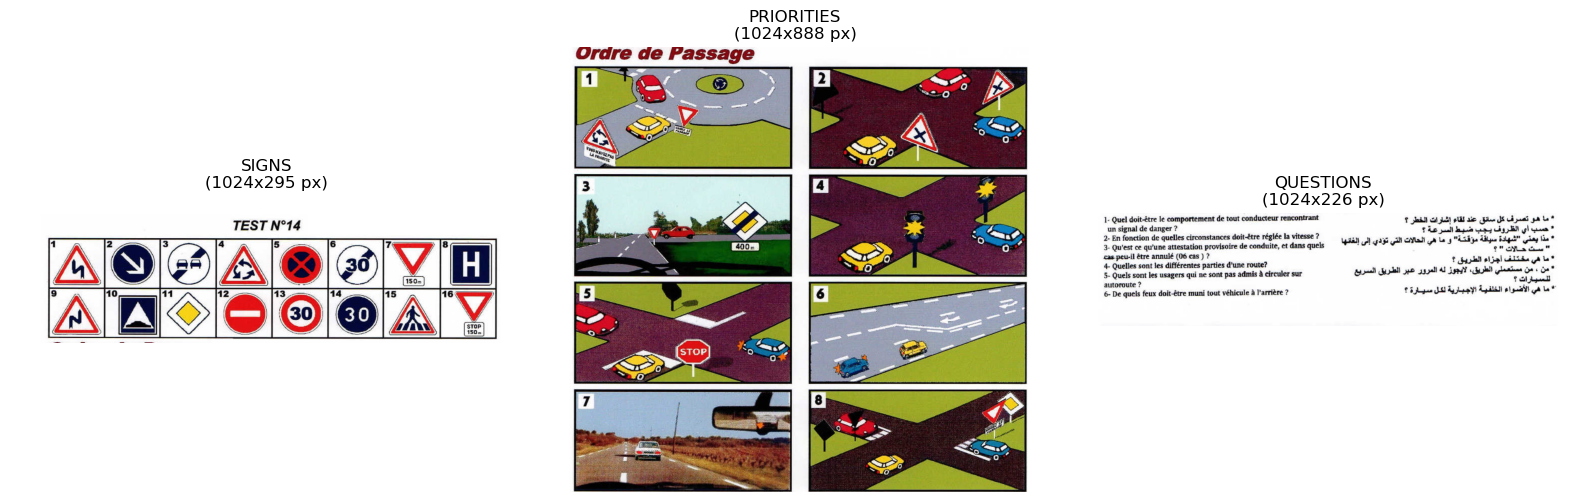

✓ Preview saved to: ..\data\quiz_sections\test-14_sections_preview.png


In [110]:
# Load and display the extracted sections from first image
first_image_stem = first_image_path.stem
first_image_output_dir = OUTPUT_DIR / first_image_stem

if first_image_output_dir.exists():
    fig, axes = plt.subplots(1, 3, figsize=(16, 8))
    
    section_names = ['SIGNS', 'PRIORITIES', 'QUESTIONS']
    
    for idx, section_name in enumerate(section_names):
        section_dir = first_image_output_dir / section_name
        section_files = list(section_dir.glob("*.png"))
        
        if section_files:
            section_img = cv2.imread(str(section_files[0]))
            
            axes[idx].imshow(cv2.cvtColor(section_img, cv2.COLOR_BGR2RGB))
            axes[idx].set_title(f"{section_name}\n({section_img.shape[1]}x{section_img.shape[0]} px)")
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{first_image_stem}_sections_preview.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Preview saved to: {OUTPUT_DIR / f'{first_image_stem}_sections_preview.png'}")
else:
    print(f"Output directory not found: {first_image_output_dir}")